In [1]:
!pip install scikit-learn --upgrade


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of projects (rows)
n_samples = 1500

# 1. Generating Features
project_types = np.random.choice(['Web Development', 'Mobile App', 'Data Science', 'UI/UX Design', 'SEO'], n_samples)
hours_estimated = np.random.randint(20, 500, n_samples)
team_size = np.random.randint(1, 6, n_samples)
company_size = np.random.choice(['Startup', 'Mid-Market', 'Enterprise'], n_samples)
experience_level = np.random.choice(['Junior', 'Mid-Level', 'Senior'], n_samples)

# 2. Defining logic for pricing
base_rates = {'Junior': 20, 'Mid-Level': 45, 'Senior': 80}
type_multipliers = {'Web Development': 1.0, 'Mobile App': 1.2, 'Data Science': 1.5, 'UI/UX Design': 0.9, 'SEO': 0.8}
company_multipliers = {'Startup': 0.8, 'Mid-Market': 1.0, 'Enterprise': 1.3}

# 3. Calculating the Target Variable (Project_Cost)
costs = []
for i in range(n_samples):
    rate = base_rates[experience_level[i]]
    t_mult = type_multipliers[project_types[i]]
    c_mult = company_multipliers[company_size[i]]

    # Base cost calculation
    base_cost = hours_estimated[i] * rate * t_mult * c_mult

    # Adding team size factor and some random noise (10%) to make it realistic
    final_cost = base_cost + (team_size[i] * 500) + np.random.normal(0, base_cost * 0.1)

    # Ensure no negative costs, just in case
    final_cost = max(500, final_cost)
    costs.append(round(final_cost, 2))

# 4. Creating the DataFrame
df = pd.DataFrame({
    'Project_Type': project_types,
    'Hours_Estimated': hours_estimated,
    'Team_Size': team_size,
    'Company_Size': company_size,
    'Experience_Required': experience_level,
    'Project_Cost': costs
})

# 5. Saving to CSV
df.to_csv('project_cost_data.csv', index=False)
df.head()

,Project_Type,Hours_Estimated,Team_Size,Company_Size,Experience_Required,Project_Cost
0,UI/UX Design,371,4,Enterprise,Senior,33099.76
1,SEO,261,1,Mid-Market,Senior,17838.09
2,Data Science,343,4,Mid-Market,Mid-Level,22292.33
3,SEO,238,4,Enterprise,Senior,20733.87
4,SEO,211,4,Mid-Market,Junior,5482.19


In [3]:
df.info()
print("---------")
df.describe()
print("---------")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Project_Type         1500 non-null   object 
 1   Hours_Estimated      1500 non-null   int32  
 2   Team_Size            1500 non-null   int32  
 3   Company_Size         1500 non-null   object 
 4   Experience_Required  1500 non-null   object 
 5   Project_Cost         1500 non-null   float64
dtypes: float64(1), int32(2), object(3)
memory usage: 58.7+ KB
---------
---------


<Axes: xlabel='Hours_Estimated', ylabel='Project_Cost'>

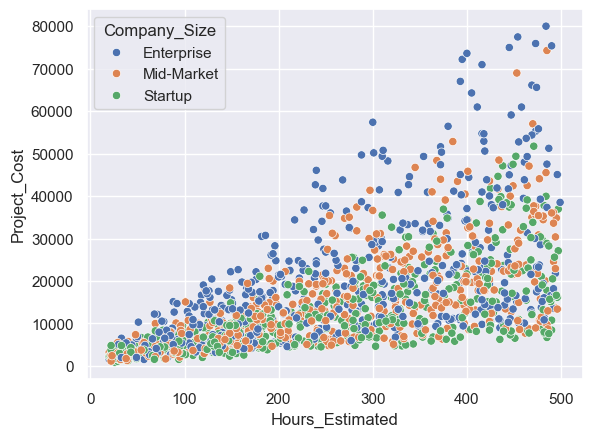

In [4]:
import seaborn as sns

sns.set_theme(style="darkgrid")

sns.scatterplot(data=df, x="Hours_Estimated", y="Project_Cost" , hue='Company_Size')



<Axes: xlabel='Hours_Estimated', ylabel='Team_Size'>

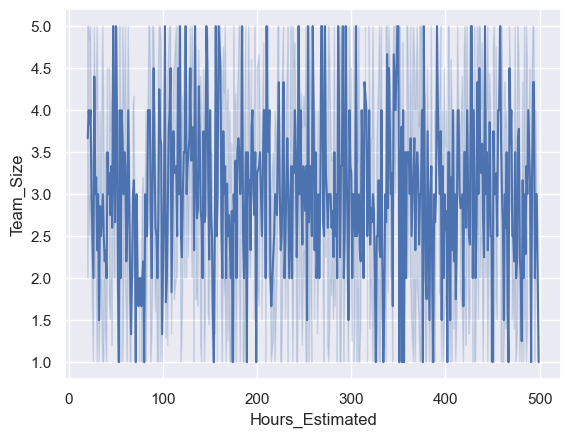

In [5]:
sns.lineplot(data=df , x = 'Hours_Estimated' , y = 'Team_Size',)

<Axes: xlabel='Project_Type', ylabel='Project_Cost'>

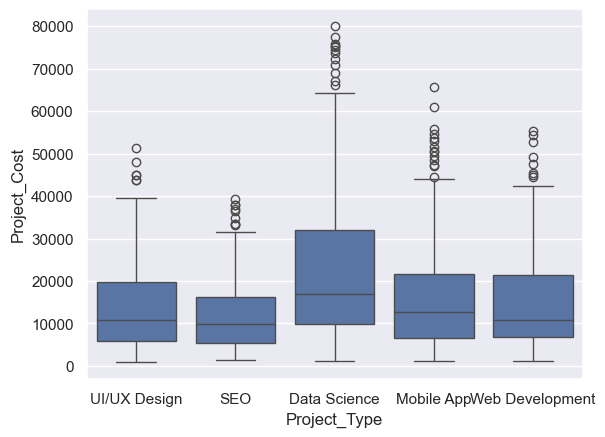

In [6]:
sns.boxplot(data=df, x="Project_Type", y="Project_Cost")

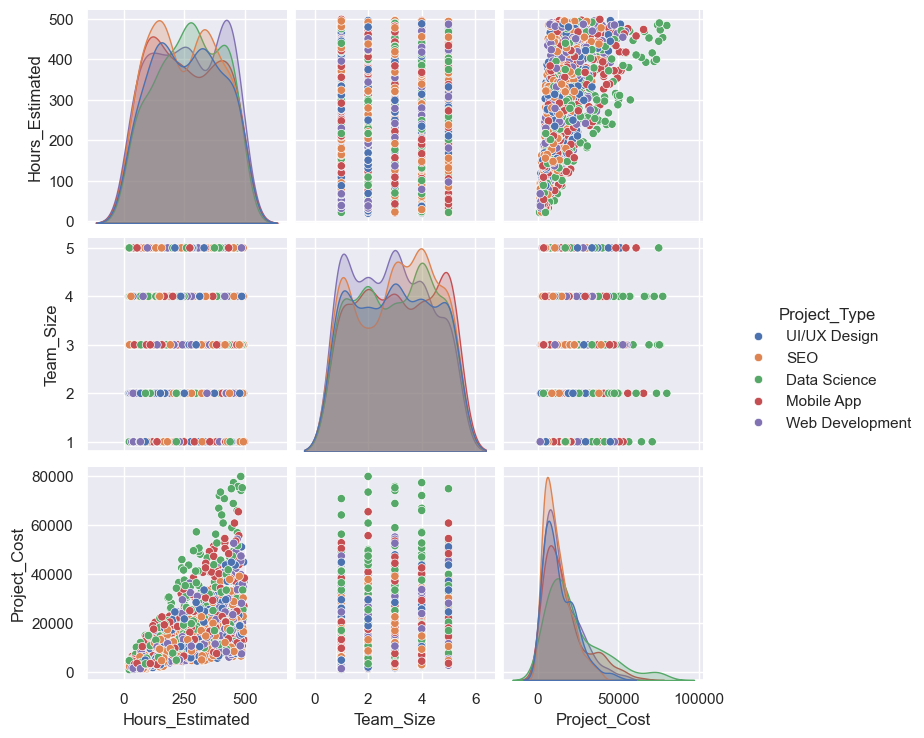

In [7]:
sns.pairplot(data=df, hue="Project_Type")

In [8]:
X = df.drop('Project_Cost', axis=1)
y = df['Project_Cost']

In [9]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y, random_state=42 , test_size=0.2)

In [10]:
from sklearn.pipeline import Pipeline

cat_featuere = ["Project_Type", "Company_Size", "Experience_Required"]
num_feature = ["Hours_Estimated", "Team_Size"]

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor = ColumnTransformer(transformers=[
    ('num' , StandardScaler() , num_feature),
    ('cat' , OneHotEncoder() , cat_featuere)
])

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'SVR': SVR()
}


In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

for name, model in models.items():

    cl_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cl_pipeline.fit(X_train, y_train)

    y_pred = cl_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f" {name}:")
    print(f"   - الخطأ في السعر (MAE): ${mae:.2f}")
    print(f"   - كفاءة التوقع (R2): {r2:.4f}")
    print("-" * 30)

 LinearRegression:
   - الخطأ في السعر (MAE): $3702.59
   - كفاءة التوقع (R2): 0.8101
------------------------------
 DecisionTreeRegressor:
   - الخطأ في السعر (MAE): $1989.13
   - كفاءة التوقع (R2): 0.9369
------------------------------
 RandomForestRegressor:
   - الخطأ في السعر (MAE): $1509.89
   - كفاءة التوقع (R2): 0.9607
------------------------------
 SVR:
   - الخطأ في السعر (MAE): $8334.92
   - كفاءة التوقع (R2): -0.0434
------------------------------


In [14]:
from sklearn.model_selection import GridSearchCV

grid_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor())
    ])


In [15]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

In [16]:
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [17]:
grid_search.fit(X_train , y_train)


best_model = grid_search.best_estimator_

best_prediction = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test , best_prediction)

best_r2 = r2_score(y_test , best_prediction)

print("\n أفضل معاملات تم اختيارها:")
print(grid_search.best_params_)
print("-" * 30)
print(f"الخطأ الجديد (MAE): ${best_mae:.2f}")
print(f"الكفاءة الجديدة (R2): {best_r2:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits



 أفضل معاملات تم اختيارها:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
------------------------------
الخطأ الجديد (MAE): $1498.72
الكفاءة الجديدة (R2): 0.9608


In [ ]:
"""import joblib
from google.colab import files

joblib.dump(best_model, 'project_cost_model.pkl')

print("تم حفظ الموديل بنجاح في ملف 'project_cost_model.pkl'")
files.download('project_cost_model.pkl')"""